# Finsler Flow Matching on the ForkSheet

A bifurcation on a curved sheet. $p_0$ is the trunk plus the first part of the fork,
$p_1$ is the tips of both arms, and the stretch over which the two arms resolve is
withheld. Both arms are curved and neither is the other's mirror; the two fates carry
equal mass. Runtime $\approx$ 10 GPU-min.


In [1]:
%matplotlib inline
import matplotlib
_NB_BACKEND = matplotlib.get_backend()
import pathlib
import sys
_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import contextlib
import dataclasses
import io
import json
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch

from scripts.experiments.forksheet.datasets import (FATE_NAMES, GAP, SOURCE, TARGET,
                                                    fate_balls, fate_inside, fate_resolved,
                                                    fate_scored, fate_table, make_dataset)
from scripts.experiments.forksheet.figures import fork_primitives
from scripts.experiments.sheet.evaluate import evaluate_route
from scripts.experiments.sheet.paper_focus import (PATHB_NAME, QUAL_DET,
                                                   QUAL_NOISY, two_line)
from scripts.experiments.sheet.protocol import corridor_mask, pooled_slices
from scripts.experiments.sheet.split import (make_split, split_route_eval,
                                             split_training_set)
from scripts.core.arms import HParams, run_arm
from scripts.core.metrics import mean_floor
from scripts.core.paths import figure_dir, rel   # notebooks/out, or out_smoke
import scripts.method
from scripts.method import (FWFactory, Run, cuda_warm_up, euclidean_w2, finsler_w2,
                            moments_from, path_a, path_b, results_table, seed_frame,
                            sigma_for)
from scripts.method import figures as nbfig

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

matplotlib.use(_NB_BACKEND)

pf = fork_primitives()
pd.set_option("display.width", 200)

## Hyperparameters
Carried over from the Sheet, which was tuned with scripts/experiments/sheet/tune.py; the
values are asserted against scripts/experiments/sheet/tuned.json rather than restated, and
no point was selected on this cloud.


In [2]:
cfg = Run.from_env()

TUNED = json.loads((PUBLIC / "scripts/experiments/sheet/tuned.json").read_text())
assert set(TUNED) == {"ffm", "mfm_land", "curly", "cfm", "pathb"}, sorted(TUNED)
print(TUNED)

FFM_DET = f"{PATHB_NAME} (ours), {QUAL_DET}"
FFM_SDE = f"{PATHB_NAME} (ours), {QUAL_NOISY}"

{'ffm': {'rho_mult': 1.0, 'lam_mult': 0.3}, 'mfm_land': {'land_rho': 0.001}, 'curly': {'curly_alpha': 1.0}, 'cfm': {}, 'pathb': {'width_mult': 0.3}}


## Dataset


p0 969  p1 631
withheld: 357 cells
p0 fate mass  lower arm 0.500  upper arm 0.500
gap fate mass  lower arm 0.501  upper arm 0.499
p1 fate mass  lower arm 0.499  upper arm 0.501


wrote notebooks/out/forksheet_dataset.png


wrote notebooks/out/forksheet_dataset.pdf


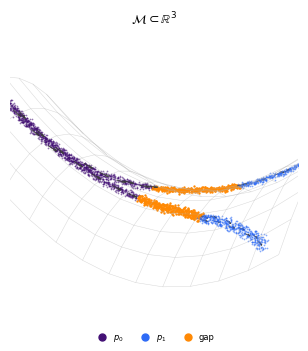

In [3]:
ds    = make_dataset("ForkSheet")                  # N = 3000, d = 3
split = make_split(ds, seed=cfg.split_seed)        # drawn once and held fixed
ts    = split_training_set(ds, split)
rev   = split_route_eval(ds, split, "test")        # the withheld gap + p_1

X, P = np.asarray(ts.X, dtype=np.float64), sp.csr_matrix(ts.P)
N, d = X.shape
p0_mask, p1_mask = ts.p0, ts.p1
X_t  = cfg.tensor(X)
X0_t = X_t[torch.as_tensor(p0_mask, device=cfg.device)]
X1_t = X_t[torch.as_tensor(p1_mask, device=cfg.device)]

print(f"p0 {int(p0_mask.sum())}  p1 {int(p1_mask.sum())}")
print(f"withheld: {len(rev.corridor_ref)} cells")
for _nm, _reg in (("p0", SOURCE), ("gap", GAP), ("p1", TARGET)):
    _lab = ds.fate[ds.region == _reg]
    print(f"{_nm} fate mass  " + "  ".join(f"{FATE_NAMES[f]} {float((_lab == f).mean()):.3f}"
                                           for f in sorted(FATE_NAMES)))

b0_pts, D_pts = moments_from(P, X)
fw = FWFactory(X, D_pts, b0_pts, cfg,
               rho_mult=TUNED["ffm"]["rho_mult"], lam_mult=TUNED["ffm"]["lam_mult"])


_u, _w = ds.uv[ts.idx, 0], ds.uv[ts.idx, 1]
_corr  = corridor_mask(ds)
_LO, _HI = pf._limits(ds)

fig = plt.figure(figsize=(5.0, 3.4), layout="constrained")
ax3 = fig.add_subplot(111, projection="3d")
pf._surface(ax3, ds, alpha=0.5, lw=0.35)
pf._scatter_cloud(ax3, ds, _corr, three_d=True, s=1.5, alpha_scale=1.35)


_A_LEN = 0.10
_Pasym = (P - P.T) * 0.5
_J_pts = np.asarray(_Pasym @ X) - np.asarray(_Pasym.sum(axis=1)) * X

_g = nbfig.bin_flux(np.c_[_u, _w], _J_pts[:, :2], nu=15, nw=13, min_count=6)
_zu, _zw = pf._fork_dz(_g[:, 0], _g[:, 1])
_a_vec = np.c_[_g[:, 2], _g[:, 3], _zu * _g[:, 2] + _zw * _g[:, 3]]
_a_vec *= _A_LEN / (np.linalg.norm(_a_vec, axis=1, keepdims=True) + 1e-12)
_a_xyz = np.c_[_g[:, :2], pf._fork_z(_g[:, 0], _g[:, 1])] - _a_vec / 2
ax3.quiver(*_a_xyz.T, *_a_vec.T, color="#3a3a3a", linewidth=0.75, arrow_length_ratio=0.4,
           alpha=0.9, zorder=3)

pf._style_3d(ax3, _LO, _HI, zoom=1.4)      # a wider cell than the paths figure's
ax3.set_title(r"$\mathcal{M} \subset \mathbb{R}^3$", fontsize=cfg.fs_heading + 1, pad=-4)

fig.legend(handles=pf._legend_handles(ds, _corr, extra_paths=False),
           loc="outside lower center", ncol=3, frameon=False,
           fontsize=cfg.fs_legend + 1, handletextpad=0.3, columnspacing=1.6)

_stem = pathlib.Path(figure_dir(cfg.smoke)) / "forksheet_dataset"
_stem.parent.mkdir(parents=True, exist_ok=True)
for _ext in ("png", "pdf"):
    fig.savefig(_stem.with_suffix(f".{_ext}"), dpi=300, bbox_inches="tight")
    print(f"wrote {rel(_stem.with_suffix('.' + _ext))}")
plt.show()

## Run


In [4]:
metric_star = fw.at(rho=fw.rho_rungs([TUNED["ffm"]["rho_mult"]])[0],
                    lam=fw.lam_rungs([TUNED["ffm"]["lam_mult"]])[0])

if cuda_warm_up(metric_star, X0_t, X1_t, cfg):
    print("cuda warm-up done, discarded -- scripts.method.phases.cuda_warm_up says why\n")

runs = {}
for seed in cfg.seeds:
    t0 = time.time()
    print(f"--- {FFM_DET}  seed {seed} ---")
    out = path_a(metric_star, X0_t, X1_t, seed, cfg, verbose=(seed == cfg.seeds[0]))
    out["sigma"] = 0.0
    out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                    device=cfg.device, dtype=cfg.dtype, seed=0)
    runs[(FFM_DET, seed)] = out
    m = out["metrics"]
    print(f"    mid W2 {m['intermediate']['W2']:.4f}   "
          f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.1f}s)")

cuda warm-up done, discarded -- scripts.method.phases.cuda_warm_up says why

--- FFM (ours), deterministic  seed 0 ---
    iter     0  L_geo 0.72370


    iter   250  L_geo 0.47240


    iter   500  L_geo 0.39501


    iter   750  L_geo 0.34759


    iter  1000  L_geo 0.35339


...

    iter  1250  L_CFM 0.04419


    iter  1499  L_CFM 0.04333


    mid W2 0.2699   end W2 0.4547   (34.5s)
--- FFM (ours), deterministic  seed 1 ---


    mid W2 0.2408   end W2 0.5872   (30.7s)
--- FFM (ours), deterministic  seed 2 ---


    mid W2 0.2565   end W2 0.4964   (30.8s)


## Baselines


In [5]:
BASE_N_STEPS = 102
BASELINES = {"OT-CFM": "cfm", "MFM / LAND": "mfm_land", "Curly-FM": "curly"}


ts_base = dataclasses.replace(ts, velocity=b0_pts)
assert np.allclose(ts_base.velocity, moments_from(P, X)[0]), \
    "Curly-FM's channel must be the first moment sum_j P_ij (x_j - x_i)"
assert not np.allclose(ts_base.velocity, ds._v_gen[ts.idx]), \
    "Curly-FM must never see the generator velocity field -- only P is public"


base_hp = cfg.arm_kw
assert base_hp["width"] == cfg.net_width and base_hp["depth"] == cfg.net_depth
assert base_hp["curly_net"] == "shared"

base_tuned = {label: TUNED[arm] for label, arm in BASELINES.items()}


def run_baseline(label, seed, **over):
    """One engine arm at one point, in this notebook's ``runs`` shape."""
    hp = HParams(**{**base_hp, **over})
    res = run_arm(BASELINES[label], ts_base, hp, seed, cfg.device, cfg.dtype,
                  n_steps=BASE_N_STEPS)
    return {"phi": None, "v_net": res.v_net, "sigma": 0.0,
            "traj": np.asarray(res.traj, dtype=np.float64), "ot": res.diag}


for label, point in base_tuned.items():
    print(f"{label:12s} {point or 'nothing to select'}")
    for seed in cfg.seeds:
        t0 = time.time()
        out = run_baseline(label, seed, **point)
        out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                        device=cfg.device, dtype=cfg.dtype, seed=0)
        runs[(label, seed)] = out
        m = out["metrics"]
        print(f"{label:12s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
              f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.0f}s)")

OT-CFM       nothing to select
    [cfm]    iter     0  L_CFM = 1.629270


    [cfm]    iter   250  L_CFM = 0.073114


    [cfm]    iter   500  L_CFM = 0.037410


    [cfm]    iter   750  L_CFM = 0.028909


    [cfm]    iter  1000  L_CFM = 0.026239


...

    [phase2] iter  1499  L_CFM = 0.058948


MFM / LAND   seed 2   mid W2 0.4931   end W2 2.1207   (30s)
Curly-FM     {'curly_alpha': 1.0}


Curly-FM     seed 0   mid W2 0.3057   end W2 0.4098   (56s)


Curly-FM     seed 1   mid W2 0.3166   end W2 0.4803   (49s)


Curly-FM     seed 2   mid W2 0.2821   end W2 0.3082   (48s)


## FFM with noise


In [6]:
SIGMA_B = sigma_for(metric_star, TUNED["pathb"]["width_mult"])

for seed in cfg.seeds:
    t0 = time.time()
    ref = runs[(FFM_DET, seed)]
    out = path_b(metric_star, ref["phi"], ref["coupler"], X0_t, SIGMA_B, seed, cfg,
                 verbose=(seed == cfg.seeds[0]))
    out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                    device=cfg.device, dtype=cfg.dtype, seed=0)
    runs[(FFM_SDE, seed)] = out
    m = out["metrics"]
    print(f"{FFM_SDE:28s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
          f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.0f}s)")

REPORTED = [FFM_DET, FFM_SDE, *BASELINES]

    iter     0  L_CFM 1.97143  L_CSM 1464.71411


    iter   250  L_CFM 0.08034  L_CSM 1582.61560


    iter   500  L_CFM 0.04400  L_CSM 1702.15369


    iter   750  L_CFM 0.03826  L_CSM 1747.95789


    iter  1000  L_CFM 0.04393  L_CSM 1702.88525


    iter  1250  L_CFM 0.04812  L_CSM 1724.59570


    iter  1499  L_CFM 0.03629  L_CSM 1733.29871


FFM (ours), with noise       seed 0   mid W2 0.2764   end W2 0.4874   (17s)


FFM (ours), with noise       seed 1   mid W2 0.2675   end W2 0.6760   (17s)


FFM (ours), with noise       seed 2   mid W2 0.2984   end W2 0.8387   (18s)


## Table


In [7]:
COLUMNS = {**scripts.method.BASE_COLUMNS, "cos(v, b0)": ("drift", "cos")}
print(results_table(runs, REPORTED, cfg.seeds, COLUMNS,
                    floors=runs[(FFM_DET, cfg.seeds[0])]["metrics"]["floors"]).to_string())

                                    mid W2           end W2       cos(v, b0)
FFM (ours), deterministic  0.2557 ± 0.0119  0.5128 ± 0.0553  0.9151 ± 0.0187
FFM (ours), with noise     0.2808 ± 0.0130  0.6674 ± 0.1436  0.8629 ± 0.0767
OT-CFM                     0.3678 ± 0.0197  0.2304 ± 0.0238  0.6805 ± 0.0055
MFM / LAND                 0.3755 ± 0.0841  1.2562 ± 0.6163  0.8240 ± 0.0591
Curly-FM                   0.3014 ± 0.0144  0.3994 ± 0.0706  0.7319 ± 0.0183
sampling floor                      0.1008           0.2883               --


## Finsler Wasserstein


In [8]:
JUDGE = (runs[(FFM_DET, cfg.seeds[0])]["phi"], metric_star)

_corr_ref = np.asarray(rev.corridor_ref, dtype=np.float64)
_fl = mean_floor(_corr_ref, len(pooled_slices(runs[(FFM_DET, cfg.seeds[0])]["traj"],
                                              rev.t_lo, rev.t_hi)),
                 lambda a, b, k: {"WF": finsler_w2(a, b, JUDGE, cfg, seed=k),
                                  "WE": euclidean_w2(a, b, seed=k)})

wf_rows, eu_rows = {}, {}
for nm in REPORTED:
    _clouds = [pooled_slices(runs[(nm, s)]["traj"], rev.t_lo, rev.t_hi) for s in cfg.seeds]
    _v = [finsler_w2(c, _corr_ref, JUDGE, cfg, seed=s) for c, s in zip(_clouds, cfg.seeds)]
    wf_rows[nm] = (float(np.mean(_v)), float(np.std(_v)))
    eu_rows[nm] = float(np.mean([euclidean_w2(c, _corr_ref, seed=s)
                                 for c, s in zip(_clouds, cfg.seeds)]))

print(f"Finsler Wasserstein  W_2,F  between the pooled t in [{rev.t_lo:.2f}, "
      f"{rev.t_hi:.2f}] cloud and the {len(_corr_ref)} withheld gap cells,")
print(f"under c_F from the FFM metric.  Path B rows were integrated under the SDE.\n")
_w2 = max(len(n) for n in REPORTED) + 2
print(f"{'':<{_w2}s}{'W_2,F':>18s}{'Euclidean W_2':>18s}")
for nm in REPORTED:
    print(f"{nm:<{_w2}s}{wf_rows[nm][0]:>11.4f} ± {wf_rows[nm][1]:.4f}{eu_rows[nm]:>18.4f}")
print(f"{'sampling floor':<{_w2}s}{_fl['WF']:>18.4f}"
      f"{_fl['WE']:>18.4f}")

Finsler Wasserstein  W_2,F  between the pooled t in [0.45, 0.70] cloud and the 357 withheld gap cells,
under c_F from the FFM metric.  Path B rows were integrated under the SDE.

                                        W_2,F     Euclidean W_2
FFM (ours), deterministic       0.1828 ± 0.0061            0.2523
FFM (ours), with noise          0.1824 ± 0.0054            0.2717
OT-CFM                          0.2110 ± 0.0018            0.3718
MFM / LAND                      0.1867 ± 0.0243            0.3771
Curly-FM                        0.2120 ± 0.0097            0.3099
sampling floor                         0.1589            0.1008


## Fate
Which arm each cell ended up on. One region per arm, centred on that arm's $p_1$ centroid
with radius half the distance between the two centres — the largest radius at which nothing
can lie in both, so it is forced by the geometry rather than chosen.

Each region is **cut at its centre and opened outward**: a cell that sails past the tip of
its own arm chose that arm, and how far past it went is a distance, which the endpoint $W_2$
above already reports. That is not a corner case here — 95% of FFM's would-be-outside mass
is overshoot, because the Finsler geodesic arrives at full speed ($|\dot x| \approx 4.5$ at
$t = 1$ against OT-CFM's $\approx 1.0$). Undershoot and sideways flight still leave the
region.

Rows are the source cell's true lineage (`ds.fate`, fixed when the cloud was drawn and never
a model input), columns *recall* on that arm's own region, the *wrong arm*, and *outside*,
in percent, and each row sums to $100$. Trajectory column $j$ is source cell $j$: the
integrator starts at $x_0$ and never reorders. Cells whose two bands still overlap at
$t = 0$ are dropped — their arm is not observable, so no method
could route them.

Conditioning on the true lineage is what a share cannot do: an arm that swaps the two
lineages wholesale reproduces the target split exactly and lands wholly off the diagonal
here. The scale is fixed by two references — **perfect transport**, each cell on a random
$p_1$ cell of its own arm, is the identity; **no transport** is entirely *outside*.

In [9]:
SRC = ts.idx[ts.p0]
FATE_KEYS, FATE_CENTRES, FATE_AXES, FATE_R = fate_balls(ds)
ARM_COLS = ["recall", "wrong arm", "outside"]


def perfect_transport(d, src, seed=0):
    """Every source cell put on a random p_1 cell of its own arm."""
    rng = np.random.default_rng(seed)
    tgt = np.flatnonzero(d.region == TARGET)
    return d.X[[rng.choice(tgt[d.fate[tgt] == f]) for f in d.fate[src]]]


def arm_split(tab, i):
    """Arm ``i``'s row of a fate table as (recall, wrong arm, outside), in percent."""
    row = 100.0 * np.asarray(tab, dtype=np.float64)[i]
    return np.array([row[i], row[:-1].sum() - row[i], row[-1]])


def pct(vals):
    """Mean +/- population sd over seeds of an already-percent quantity."""
    v = np.asarray(vals, dtype=np.float64)
    return f"{v.mean():.1f} ± {v.std():.1f}"


def ball_rows(tabs, name):
    """One row per true arm: mean +/- sd over seeds of where that arm's cells landed."""
    T = np.stack([[arm_split(t, i) for i in range(len(FATE_KEYS))] for t in tabs])
    return {(name, FATE_NAMES[f]):
            {c: pct(T[:, i, j]) for j, c in enumerate(ARM_COLS)}
            for i, f in enumerate(FATE_KEYS)}


ball_tab = {}
for nm in REPORTED:
    ball_tab.update(ball_rows([fate_table(ds, SRC, runs[(nm, s)]["traj"][-1])
                               for s in cfg.seeds], nm))
ball_tab.update(ball_rows([fate_table(ds, SRC, perfect_transport(ds, SRC))],
                          "perfect transport"))
ball_tab.update(ball_rows([fate_table(ds, SRC, ds.X[SRC])], "no transport"))

print(f"balls of radius {FATE_R:.3f} on the two $p_1$ centres, "
      f"{np.linalg.norm(FATE_CENTRES[0] - FATE_CENTRES[1]):.3f} apart, "
f"opened outward")
print(f"{int(fate_resolved(ds, SRC).sum())} of {len(SRC)} source cells have their arm "
      f"resolved at t = 0")
print(f"percent, mean ± population sd over {len(cfg.seeds)} "
      f"seed{'s' if len(cfg.seeds) > 1 else ''}\n")
print(pd.DataFrame(ball_tab).T.to_string())


balls of radius 0.685 on the two $p_1$ centres, 1.371 apart, opened outward
324 of 969 source cells have their arm resolved at t = 0
percent, mean ± population sd over 3 seeds

                                          recall    wrong arm      outside
FFM (ours), deterministic lower arm  75.5 ± 19.7  21.2 ± 19.4    3.4 ± 0.3
                          upper arm  100.0 ± 0.0    0.0 ± 0.0    0.0 ± 0.0
FFM (ours), with noise    lower arm  68.3 ± 19.8  20.8 ± 22.7  10.9 ± 12.7
                          upper arm   98.8 ± 0.9    0.0 ± 0.0    1.2 ± 0.9
OT-CFM                    lower arm  69.4 ± 10.7  30.6 ± 10.7    0.0 ± 0.0
                          upper arm  100.0 ± 0.0    0.0 ± 0.0    0.0 ± 0.0
MFM / LAND                lower arm   91.4 ± 5.6    4.4 ± 3.9    4.2 ± 3.4
                          upper arm  68.1 ± 37.3  12.3 ± 17.4  19.6 ± 20.1
Curly-FM                  lower arm  48.8 ± 16.7  47.4 ± 15.2    3.8 ± 1.5
                          upper arm  100.0 ± 0.0    0.0 ± 0.0    0.0 ± 0.

## Fate imbalance

In [10]:
SHARE_GRID = [(0.5, 0.5), (0.7, 0.3), (0.4, 0.6), (0.2, 0.8), (0.1, 0.9)]
SWEEP_SEEDS = list(cfg.seeds)
if cfg.smoke:
    SHARE_GRID = SHARE_GRID[:2]

sweep = {}
for _sh in SHARE_GRID:
    _tag = f"{_sh[0] * 100:.0f}/{_sh[1] * 100:.0f}"
    with contextlib.redirect_stdout(io.StringIO()):     # the engine arms log per phase
        ds_i  = make_dataset("ForkSheet", shares=_sh)
        spl_i = make_split(ds_i, seed=cfg.split_seed)
        ts_i  = split_training_set(ds_i, spl_i)
        rev_i = split_route_eval(ds_i, spl_i, "test")

        X_i, P_i = np.asarray(ts_i.X, dtype=np.float64), sp.csr_matrix(ts_i.P)
        b0_i, D_i = moments_from(P_i, X_i)
        _Xt  = cfg.tensor(X_i)
        X0_i = _Xt[torch.as_tensor(ts_i.p0, device=cfg.device)]
        X1_i = _Xt[torch.as_tensor(ts_i.p1, device=cfg.device)]

        fw_i = FWFactory(X_i, D_i, b0_i, cfg, rho_mult=TUNED["ffm"]["rho_mult"],
                         lam_mult=TUNED["ffm"]["lam_mult"])
        m_i = fw_i.at(rho=fw_i.rho_rungs([TUNED["ffm"]["rho_mult"]])[0],
                      lam=fw_i.lam_rungs([TUNED["ffm"]["lam_mult"]])[0])

        ts_bi = dataclasses.replace(ts_i, velocity=b0_i)
        trajs = {nm: [] for nm in REPORTED}
        for _sd in SWEEP_SEEDS:
            _a = path_a(m_i, X0_i, X1_i, _sd, cfg)
            _b = path_b(m_i, _a["phi"], _a["coupler"], X0_i,
                        sigma_for(m_i, TUNED["pathb"]["width_mult"]), _sd, cfg)
            trajs[FFM_DET].append(_a["traj"])
            trajs[FFM_SDE].append(_b["traj"])
            for label in BASELINES:
                _res = run_arm(BASELINES[label], ts_bi,
                               HParams(**{**base_hp, **base_tuned[label]}), _sd,
                               cfg.device, cfg.dtype, n_steps=BASE_N_STEPS)
                trajs[label].append(np.asarray(_res.traj, dtype=np.float64))

    _src = ts_i.idx[ts_i.p0]
    _er = np.asarray(rev_i.endpoint_ref, dtype=np.float64)

    _perf, _perf_w2 = [], []
    for _sd in SWEEP_SEEDS:
        _perf.append(perfect_transport(ds_i, _src, seed=_sd))
        _perf_w2.append(mean_floor(_er, len(_perf[-1]),
                                   lambda a, b, k: {"W2": euclidean_w2(a, b, seed=k)},
                                   _sd)["W2"])

    # the cloud and one seed's t = 1 endpoints are kept, not just the scores: the regions
    # figure below redraws these very points, and rerunning the arm to plot it would not be it
    sweep[_tag] = {
        "ds": ds_i, "src": _src,
        "arms": {
            "perfect transport": {
                "tabs": [fate_table(ds_i, _src, e) for e in _perf], "end": _perf[0],
                "w2s": _perf_w2},
            **{nm: {"tabs": [fate_table(ds_i, _src, tr[-1]) for tr in trs],
                    "end": trs[0][-1],
                    "w2s": [euclidean_w2(tr[-1], _er, seed=0) for tr in trs]}
               for nm, trs in trajs.items()}}}

    print(f"--- shares {_tag}   ({FATE_NAMES[0]}/{FATE_NAMES[1]})   "
          f"percent, mean ± population sd over {len(SWEEP_SEEDS)} "
          f"seed{'s' if len(SWEEP_SEEDS) > 1 else ''} ---")
    for nm in (*REPORTED, "perfect transport"):
        _c = sweep[_tag]["arms"][nm]
        _own = "   ".join(f"{FATE_NAMES[f]} {pct([arm_split(t, i)[0] for t in _c['tabs']])}"
                          for i, f in enumerate(FATE_KEYS))
        _out = pct([np.mean([arm_split(t, i)[2] for i in range(len(FATE_KEYS))])
                    for t in _c["tabs"]])
        _w2 = np.asarray(_c["w2s"], dtype=np.float64)
        print(f"    {nm:28s} recall  {_own}   outside {_out}"
              f"   end W2 {_w2.mean():.4f} ± {_w2.std():.4f}")


--- shares 50/50   (lower arm/upper arm)   percent, mean ± population sd over 3 seeds ---
    FFM (ours), deterministic    recall  lower arm 95.6 ± 3.4   upper arm 94.1 ± 5.2   outside 3.3 ± 1.5   end W2 0.4838 ± 0.1054
    FFM (ours), with noise       recall  lower arm 97.3 ± 3.4   upper arm 94.5 ± 7.7   outside 2.2 ± 1.9   end W2 0.4333 ± 0.0159
    OT-CFM                       recall  lower arm 69.4 ± 10.7   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2304 ± 0.0238
    MFM / LAND                   recall  lower arm 91.2 ± 9.5   upper arm 76.0 ± 16.6   outside 13.5 ± 11.0   end W2 1.0073 ± 0.3991
    Curly-FM                     recall  lower arm 48.8 ± 16.7   upper arm 100.0 ± 0.0   outside 1.9 ± 0.8   end W2 0.3994 ± 0.0706
    perfect transport            recall  lower arm 100.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2937 ± 0.0297


--- shares 70/30   (lower arm/upper arm)   percent, mean ± population sd over 3 seeds ---
    FFM (ours), deterministic    recall  lower arm 92.2 ± 10.4   upper arm 89.1 ± 13.9   outside 8.7 ± 6.0   end W2 0.4924 ± 0.0371
    FFM (ours), with noise       recall  lower arm 94.0 ± 8.5   upper arm 81.2 ± 19.5   outside 10.4 ± 6.5   end W2 0.4318 ± 0.0707
    OT-CFM                       recall  lower arm 71.1 ± 2.5   upper arm 100.0 ± 0.0   outside 0.1 ± 0.1   end W2 0.3347 ± 0.0388
    MFM / LAND                   recall  lower arm 99.9 ± 0.2   upper arm 84.8 ± 1.8   outside 5.9 ± 1.2   end W2 2.6736 ± 3.1221
    Curly-FM                     recall  lower arm 68.0 ± 7.1   upper arm 100.0 ± 0.0   outside 1.9 ± 2.0   end W2 0.3247 ± 0.0717
    perfect transport            recall  lower arm 100.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2850 ± 0.0221


--- shares 40/60   (lower arm/upper arm)   percent, mean ± population sd over 3 seeds ---
    FFM (ours), deterministic    recall  lower arm 89.4 ± 5.7   upper arm 94.2 ± 8.2   outside 3.9 ± 3.7   end W2 0.5916 ± 0.2825
    FFM (ours), with noise       recall  lower arm 93.8 ± 4.2   upper arm 98.5 ± 1.8   outside 1.2 ± 1.1   end W2 0.3791 ± 0.0281
    OT-CFM                       recall  lower arm 57.6 ± 11.7   upper arm 99.5 ± 0.7   outside 1.9 ± 2.2   end W2 0.3873 ± 0.1085
    MFM / LAND                   recall  lower arm 92.0 ± 8.3   upper arm 98.5 ± 2.2   outside 1.7 ± 1.1   end W2 0.5582 ± 0.0998
    Curly-FM                     recall  lower arm 37.2 ± 3.9   upper arm 100.0 ± 0.0   outside 2.6 ± 1.7   end W2 0.3842 ± 0.0324
    perfect transport            recall  lower arm 100.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2941 ± 0.0093


--- shares 20/80   (lower arm/upper arm)   percent, mean ± population sd over 3 seeds ---
    FFM (ours), deterministic    recall  lower arm 98.9 ± 0.8   upper arm 97.7 ± 0.8   outside 1.4 ± 0.6   end W2 0.3865 ± 0.0226
    FFM (ours), with noise       recall  lower arm 99.5 ± 0.8   upper arm 98.7 ± 0.4   outside 0.5 ± 0.4   end W2 0.3753 ± 0.0428
    OT-CFM                       recall  lower arm 59.0 ± 17.4   upper arm 99.1 ± 0.6   outside 0.7 ± 0.7   end W2 0.4657 ± 0.0840
    MFM / LAND                   recall  lower arm 73.2 ± 23.6   upper arm 74.0 ± 34.9   outside 26.3 ± 20.1   end W2 2.2650 ± 2.5183
    Curly-FM                     recall  lower arm 33.9 ± 18.8   upper arm 100.0 ± 0.0   outside 4.6 ± 4.9   end W2 0.3911 ± 0.0735
    perfect transport            recall  lower arm 100.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2690 ± 0.0087


--- shares 10/90   (lower arm/upper arm)   percent, mean ± population sd over 3 seeds ---
    FFM (ours), deterministic    recall  lower arm 77.8 ± 10.4   upper arm 98.3 ± 0.3   outside 6.4 ± 6.0   end W2 0.3604 ± 0.0305
    FFM (ours), with noise       recall  lower arm 79.6 ± 6.5   upper arm 93.1 ± 4.8   outside 7.2 ± 7.6   end W2 0.4576 ± 0.0344
    OT-CFM                       recall  lower arm 36.1 ± 16.4   upper arm 98.4 ± 1.3   outside 9.6 ± 5.8   end W2 0.6376 ± 0.0665
    MFM / LAND                   recall  lower arm 50.9 ± 15.1   upper arm 96.9 ± 4.4   outside 21.9 ± 13.9   end W2 0.6190 ± 0.1393
    Curly-FM                     recall  lower arm 0.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.9 ± 1.3   end W2 0.3915 ± 0.0480
    perfect transport            recall  lower arm 100.0 ± 0.0   upper arm 100.0 ± 0.0   outside 0.0 ± 0.0   end W2 0.2613 ± 0.0135


Rows are arms, columns the requested lower/upper split. The target is $100$ in the first two
tables and $0$ in the third, at every column.


In [11]:
SWEEP_ROWS = [*REPORTED, "perfect transport"]


def sweep_table(fn):
    return pd.DataFrame({tag: {nm: pct([fn(t) for t in col["arms"][nm]["tabs"]])
                               for nm in SWEEP_ROWS}
                         for tag, col in sweep.items()}).loc[SWEEP_ROWS].to_string()


for _i, _f in enumerate(FATE_KEYS):
    print(f"{FATE_NAMES[_f]} recall, percent, by requested lower/upper split\n")
    print(sweep_table(lambda t, i=_i: arm_split(t, i)[0]))
    print()
print("cells inside neither region, percent, mean over the two arms\n")
print(sweep_table(lambda t: np.mean([arm_split(t, i)[2] for i in range(len(FATE_KEYS))])))


lower arm recall, percent, by requested lower/upper split

                                 50/50        70/30        40/60        20/80        10/90
FFM (ours), deterministic   95.6 ± 3.4  92.2 ± 10.4   89.4 ± 5.7   98.9 ± 0.8  77.8 ± 10.4
FFM (ours), with noise      97.3 ± 3.4   94.0 ± 8.5   93.8 ± 4.2   99.5 ± 0.8   79.6 ± 6.5
OT-CFM                     69.4 ± 10.7   71.1 ± 2.5  57.6 ± 11.7  59.0 ± 17.4  36.1 ± 16.4
MFM / LAND                  91.2 ± 9.5   99.9 ± 0.2   92.0 ± 8.3  73.2 ± 23.6  50.9 ± 15.1
Curly-FM                   48.8 ± 16.7   68.0 ± 7.1   37.2 ± 3.9  33.9 ± 18.8    0.0 ± 0.0
perfect transport          100.0 ± 0.0  100.0 ± 0.0  100.0 ± 0.0  100.0 ± 0.0  100.0 ± 0.0

upper arm recall, percent, by requested lower/upper split

                                 50/50        70/30        40/60        20/80        10/90
FFM (ours), deterministic   94.1 ± 5.2  89.1 ± 13.9   94.2 ± 8.2   97.7 ± 0.8   98.3 ± 0.3
FFM (ours), with noise      94.5 ± 7.7  81.2 ± 19.5   98.5 ± 1

## Figure
Five source cells drawn at random and held fixed, so every panel shows the same five
couplings and a difference between panels is the method rather than the sample.

wrote notebooks/out/forksheet_paths.png
wrote notebooks/out/forksheet_paths.pdf


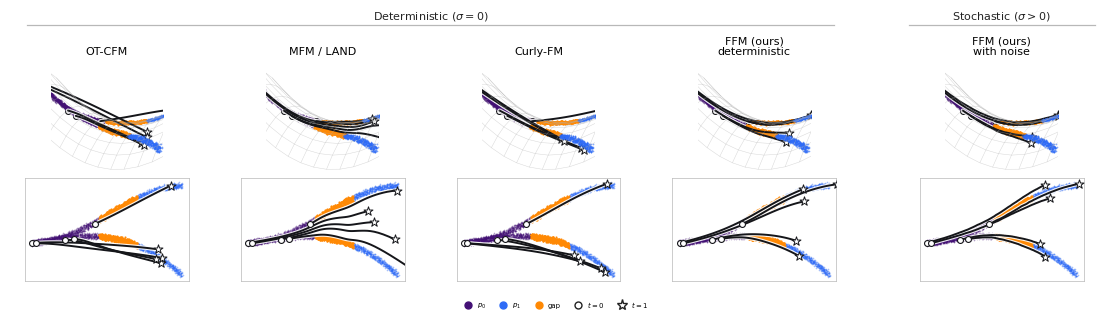

In [12]:
PATH_SEED = 0                    
N_PATHS = 5

_corr = corridor_mask(ds)
_LO, _HI = pf._limits(ds)
_PLANE_RATIO = float((_HI[1] - _LO[1]) / (_HI[0] - _LO[0])) + 0.14

FIG_BLOCKS = [
    (r"Deterministic ($\sigma = 0$)", ["OT-CFM", "MFM / LAND", "Curly-FM", FFM_DET]),
    (r"Stochastic ($\sigma > 0$)",    [FFM_SDE]),
]
FIG_LABELS = {**{nm: nm for nm in BASELINES},
              FFM_DET: two_line(QUAL_DET, ours=True),
              FFM_SDE: two_line(QUAL_NOISY, ours=True)}
 
_n_src = min(runs[(nm, cfg.seeds[0])]["traj"].shape[1] for nm in REPORTED)
assert all(np.allclose(runs[(nm, cfg.seeds[0])]["traj"][0, :_n_src],
                       runs[(FFM_DET, cfg.seeds[0])]["traj"][0, :_n_src])
           for nm in REPORTED), "the panels would not be showing the same source cells"
_cols = np.sort(np.random.default_rng(PATH_SEED).choice(_n_src, N_PATHS, replace=False))

bg = nbfig.BlockGrid(
    [(heading, [(FIG_LABELS[nm], runs[(nm, cfg.seeds[0])]["traj"][:, _cols])
                for nm in arms]) for heading, arms in FIG_BLOCKS],
    row_ratios=(0.84, _PLANE_RATIO), height=3.05, heading_fs=cfg.fs_heading)

for bi, (_heading, cols) in enumerate(bg.blocks):
    for k, (label, tr) in enumerate(cols):
        ax3 = bg.ax(1, bi, k, projection="3d")
        pf._surface(ax3, ds, alpha=0.5, lw=0.35)
        pf._scatter_cloud(ax3, ds, _corr, three_d=True, s=1.5, alpha_scale=1.35)
        pf._draw_paths(ax3, tr, three_d=True)
        pf._style_3d(ax3, _LO, _HI, zoom=pf.PANEL_ZOOM)
        ax3.set_title(label, fontsize=cfg.fs_heading, linespacing=1.1,
                      pad=-6 - cfg.fs_heading * label.count("\n"))

        ax2 = bg.ax(2, bi, k)
        pf._scatter_cloud(ax2, ds, _corr, three_d=False, s=1.4)
        pf._draw_paths(ax2, tr, three_d=False)
        pf._style_2d(ax2, _LO, _HI)

bg.legend(list(pf._legend_handles(ds, _corr, extra_paths=True)), fontsize=cfg.fs_legend)
for _p in bg.save(pathlib.Path(figure_dir(cfg.smoke)) / "forksheet_paths"):
    print(f"wrote {rel(_p)}")
plt.show()

## Fate regions

wrote notebooks/out/forksheet_fate_regions.png
wrote notebooks/out/forksheet_fate_regions.pdf


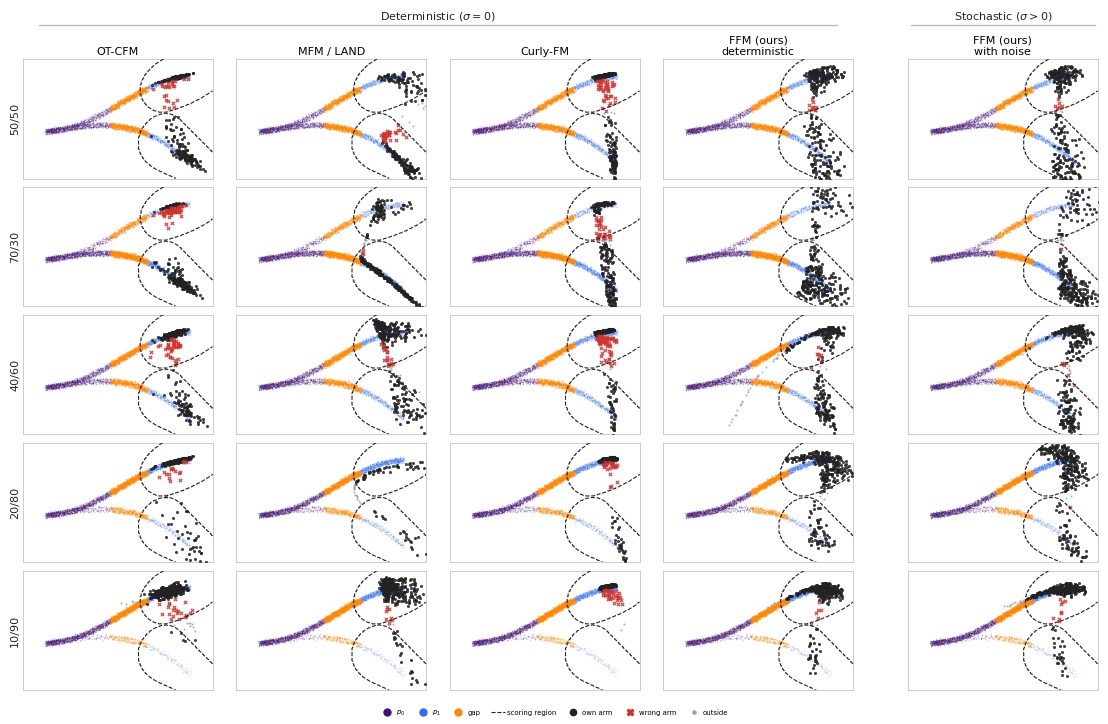

In [13]:
REG_MARKS = {"own arm":   (nbfig.INK, "o", 5.0),
             "wrong arm": ("#D1332E", "X", 9.0),
             "outside":   ("#9AA0A6", ".", 8.0)}
REG_GRID = 220                    
REG_TAGS = list(sweep)
_R_LO = np.min([pf._limits(sweep[t]["ds"], pad_frac=0.15)[0] for t in REG_TAGS], axis=0)
_R_HI = np.max([pf._limits(sweep[t]["ds"], pad_frac=0.15)[1] for t in REG_TAGS], axis=0)
_R_RATIO = float((_R_HI[1] - _R_LO[1]) / (_R_HI[0] - _R_LO[0]))


def region_outline(ax, d_i):
    """Each scoring region, restricted to the sheet, as a contour in the chart."""
    _k, _cen, _axes, _r = fate_balls(d_i)
    U, W = np.meshgrid(np.linspace(_R_LO[0], _R_HI[0], REG_GRID),
                       np.linspace(_R_LO[1], _R_HI[1], REG_GRID))
    ins = fate_inside(np.c_[U.ravel(), W.ravel(), pf._fork_z(U, W).ravel()],
                      _cen, _axes, _r)
    for i in range(len(_k)):
        ax.contour(U, W, ins[:, i].reshape(U.shape).astype(float), levels=[0.5],
                   colors=[nbfig.INK], linewidths=0.8, linestyles="--", zorder=6)


def region_marks(ax, d_i, src_i, end):
    """The scored endpoints, split into the three columns of the fate table."""
    keep, true, where = fate_scored(d_i, src_i, end)
    pts = np.asarray(end, dtype=np.float64)[keep]
    lab = np.where(where == true, 0, np.where(where == len(FATE_KEYS), 2, 1))
    for i, (colour, marker, size) in enumerate(REG_MARKS.values()):
        if (m := lab == i).any():
            ax.scatter(pts[m, 0], pts[m, 1], s=size, marker=marker, color=colour,
                       linewidths=0.0, alpha=0.85, zorder=5)


rg = nbfig.BlockGrid([(heading, list(arms)) for heading, arms in FIG_BLOCKS],
                     row_ratios=(1.0,) * len(REG_TAGS),
                     height=0.66 + 2.05 * _R_RATIO * len(REG_TAGS),
                     heading_fs=cfg.fs_heading)

for bi, (_heading, arms) in enumerate(rg.blocks):
    for k, nm in enumerate(arms):
        for ri, tag in enumerate(REG_TAGS):
            col = sweep[tag]
            ax = rg.ax(1 + ri, bi, k)
            pf._scatter_cloud(ax, col["ds"], corridor_mask(col["ds"]), three_d=False,
                              s=1.0, alpha_scale=0.5)
            region_outline(ax, col["ds"])
            region_marks(ax, col["ds"], col["src"], col["arms"][nm]["end"])
            pf._style_2d(ax, _R_LO, _R_HI)
            if ri == 0:
                ax.set_title(FIG_LABELS[nm], fontsize=cfg.fs_heading, linespacing=1.1,
                             pad=3)
            if bi == 0 and k == 0:
                ax.set_ylabel(tag, fontsize=cfg.fs_heading, color=nbfig.INK, labelpad=2)

rg.legend([*pf._legend_handles(ds, _corr, extra_paths=False),
           Line2D([], [], color=nbfig.INK, ls="--", lw=0.8, label="scoring region"),
           *(Line2D([], [], marker=mk, ls="", ms=4.5, color=c, label=nm)
             for nm, (c, mk, _s) in REG_MARKS.items())], fontsize=cfg.fs_legend)
for _p in rg.save(pathlib.Path(figure_dir(cfg.smoke)) / "forksheet_fate_regions"):
    print(f"wrote {rel(_p)}")
plt.show()